# Final Project: ECG & Temperature BLE Device

## Battery Voltage Measurement

Verify the accuracy of your battery level measurement (`AIN0`) for 0-3.7 V, as read through the nRF Connect app Bluetooth Battery Level GATT.  Quantitative analysis should include:
  * Linear regression analysis of the input voltage versus the battery level for both the `LOG_INF()` output, the oscilloscope measurement of the PWM duty cycle, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.

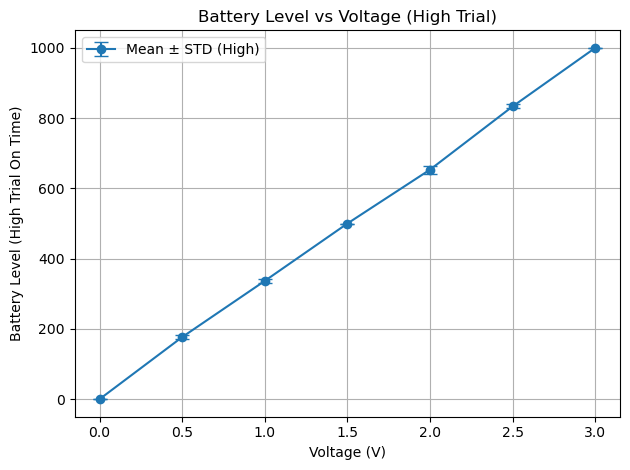

--- Linear Regression Results ---
Slope:     330.7143
Intercept: 3.9286
95% CI for Slope:     [323.9706906  337.45788083]
95% CI for Intercept: [-8.22861755 16.08576041]
R² (vs Ideal): 0.9997


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

file_path = "/Users/arshsingh/Desktop/Spring_2025/BME_554/ecg-temp-ble-project/testing/battery_test.xlsx"
df = pd.read_excel(file_path, header=1, usecols="A:D")

df.columns = ['Voltage', 'Trial 1', 'Trial 2', 'Trial 3']

df['Mean'] = df[['Trial 1', 'Trial 2', 'Trial 3']].mean(axis=1)
df['Std'] = df[['Trial 1', 'Trial 2', 'Trial 3']].std(axis=1)

plt.errorbar(
    df['Voltage'], df['Mean'], yerr=df['Std'],
    fmt='o-', capsize=5, label='Mean ± STD (High)'
)
plt.xlabel("Voltage (V)")
plt.ylabel("Battery Level (High Trial On Time)")
plt.title("Battery Level vs Voltage (High Trial)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

X = sm.add_constant(df['Voltage'])
y = df['Mean']
model = sm.OLS(y, X).fit()

intercept, slope = model.params
conf_int = model.conf_int(alpha=0.05)

ideal = (df['Voltage'] / 3.0) * 830
r_squared = np.corrcoef(df['Mean'], ideal)[0, 1] ** 2

print("--- Linear Regression Results ---")
print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"95% CI for Slope:     {conf_int.loc['Voltage'].values}")
print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
print(f"R² (vs Ideal): {r_squared:.4f}")


## ECG Heart Rate Measurement
Demonstrate that your average heart rate measurement is accurate, as recorded through `LOG_INF()` output, the oscilloscope measurements, and the nRF Connect app, relative to what was set on the function generator.  This should be done for 40, 60, 120, 150, and 180 bpm.  The 25% duty cycle should also be verified. Quantitative analysis should include:
  * Linear regression analysis of the recorded heart rate versus the set heart rate for both the `LOG_INF()` output, oscilloscope measurements, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.
  * Verification that the duty cycle of out output is 25% for all heart rates.

In [ ]:
# ECG HR Analysis Here

## Temperature Sensor Measurment

Demonstrate that your temperature sensor can have a room temperature measurement read through `LOG_INF()` output and the nRF Connect app.  Do this in 3 locations with different temperatures.  You do not need to verify accuracy, just a reasonable measurements with agreement.

In [1]:
# Temperature Sensor Verification Here